In [1]:
import os
from pathlib import Path
from PIL import Image
import numpy as np
import torch
from torch.utils.data import Dataset,DataLoader
from torchvision.transforms import functional as TF
import torch.nn.functional as F
import time
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [2]:
DATA_ROOT='../data/kvasirseg/Kvasir-SEG'
BATCH_SIZE=16
NUM_WORKERS=4
EPOCHS=100
LR=1e-3
WEIGHT_DECAY=1e-4

IMG_SIZE=256
N_CLASSES=2
IGNORE_INDEX=255
DEVICE=torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')

OUT_DIR='runs'
BEST_PATH='./runs/best_cancer_m.pt'

In [3]:
def make_transform(train):
    def _tfm(img, mask):
        img = TF.resize(img, (IMG_SIZE, IMG_SIZE))
        mask = TF.resize(mask, (IMG_SIZE, IMG_SIZE), interpolation=TF.InterpolationMode.NEAREST)

        if train and random.random() < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        img = TF.to_tensor(img)
        img = TF.normalize(img, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

        mask_np = np.array(mask)
        mask_np[mask_np > 0] = 1
        mask = torch.as_tensor(mask_np, dtype=torch.long)
        
        return img, mask
    return _tfm

class ImageMaskDataset(Dataset):
    def __init__(self, image_paths, mask_dir, tf=None):
        self.image_paths = image_paths
        self.mask_dir = Path(mask_dir)
        self.tf = tf

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        img = Image.open(img_path).convert('RGB')

        img_filename = Path(img_path).name
        mask_path = self.mask_dir / img_filename
        
        mask = Image.open(mask_path).convert('L')

        if self.tf:
            img, mask = self.tf(img, mask)
        
        return img, mask

def get_loaders(image_dir, mask_dir, train_txt_path, val_txt_path, batch_size, num_workers=4):
    with open(train_txt_path, 'r') as f:
        train_filenames = [line.strip() for line in f]
    with open(val_txt_path, 'r') as f:
        val_filenames = [line.strip() for line in f]

    tr_paths = [os.path.join(image_dir, f"{name}.jpg") for name in train_filenames]
    val_paths = [os.path.join(image_dir, f"{name}.jpg") for name in val_filenames]

    print(f"학습 데이터: {len(tr_paths)}개, 검증 데이터: {len(val_paths)}개")

    tr_ds = ImageMaskDataset(tr_paths, mask_dir, tf=make_transform(train=True))
    val_ds = ImageMaskDataset(val_paths, mask_dir, tf=make_transform(train=False))
    
    tr_loader = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)

    return tr_ds, val_ds, tr_loader, val_loader

TRIMG_DIR = Path(DATA_ROOT) / 'images'
MASK_DIR = Path(DATA_ROOT) / 'masks'

TRAIN_TXT_PATH = Path(DATA_ROOT) / 'train.txt'
VAL_TXT_PATH = Path(DATA_ROOT) / 'val.txt'

tr_ds, val_ds, tr_loader, val_loader = gezt_loaders(
    image_dir=TRIMG_DIR,
    mask_dir=MASK_DIR,
    train_txt_path=TRAIN_TXT_PATH,
    val_txt_path=VAL_TXT_PATH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

학습 데이터: 880개, 검증 데이터: 120개


In [4]:
BG_COLOR=np.array([50,50,50],dtype=np.uint8)
PET_COLOR=np.array([200,50,50],dtype=np.uint8)
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8)

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)
    
def _colorize_binary(mask_np,ignore_idx=255):
    out=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=PET_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np,mask_rgb,alpha=0.5):
    base=(img_np*255).astype(np.uint8)
    over=(alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over

def show_img_mask(ds,indices=None,n=6,alpha=0.5,ignore_idx=255):
    if indices is None:
        import random 
        n=min(n,len(ds))
        indices=random.sample(range(len(ds)),k=n)
    else:
        n=len(indices)
    r,c=n,3
    plt.figure(figsize=(c*4,r*3.5))

    for i, idx in enumerate(indices):
        sample=ds[idx]
        if len(sample)==3:
            img,mask,id_=sample
        else:
            img,mask=sample   
        img_np = _denorm(img)
        mask_np = np.array(mask)
        mask_rgb=_colorize_binary(mask_np,ignore_idx)
        over=overlay_mask(img_np,mask_rgb,alpha)

        base=i *3
        plt.subplot(r,c,base+1)
        plt.imshow(img_np)
        plt.title('img')
        plt.axis('off')
        
        plt.subplot(r,c,base+2)
        plt.imshow(mask_rgb)
        plt.title('mask')
        plt.axis('off')
        
        plt.subplot(r,c,base+3)
        plt.imshow(over)
        plt.title('overlay')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

In [5]:
import torch
import torch.nn as nn
import timm

# timm 백본을 사용하는 U-Net 클래스
class UNetWithTimm(nn.Module):
    def __init__(self, backbone_name='efficientnet_b5', in_c=3, n_classes=2, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            features_only=True,
            in_chans=in_c
        )
        encoder_channels = self.backbone.feature_info.channels()

        # 디코더 정의
        self.up1 = UP(encoder_channels[-1] + encoder_channels[-2], encoder_channels[-2])
        self.up2 = UP(encoder_channels[-2] + encoder_channels[-3], encoder_channels[-3])
        self.up3 = UP(encoder_channels[-3] + encoder_channels[-4], encoder_channels[-4])
        self.up4 = UP(encoder_channels[-4] + encoder_channels[-5], encoder_channels[-5])

        self.outc = nn.Conv2d(encoder_channels[-5], n_classes, kernel_size=1)

    def forward(self, x):
        input_size = x.shape[-2:]
        skips = self.backbone(x)
        x1, x2, x3, x4, x5 = skips

        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)

        x = F.interpolate(x, size=input_size, mode='bilinear', align_corners=False)

        out = self.outc(x)
        return out

In [6]:
os.makedirs(os.path.dirname(BEST_PATH),exist_ok=True)

BG_COLOR=np.array([50,50,50],dtype=np.uint8)
PET_COLOR=np.array([200,50,50],dtype=np.uint8)
IGNORE_COLOR=np.array([100,100,100],dtype=np.uint8)

def _denorm(img):
    mean=torch.tensor([0.485, 0.456, 0.406],device=img.device)[:,None,None]
    std=torch.tensor([0.229, 0.224, 0.225],device=img.device)[:,None,None]
    img = (img*std+mean).clamp(0,1)
    return img.detach().cpu().numpy().transpose(1,2,0)
    
def _colorize_binary(mask_np,ignore_idx=255):
    out=np.zeros((*mask_np.shape,3),dtype=np.uint8)
    out[mask_np == 0]=BG_COLOR
    out[mask_np == 1]=PET_COLOR
    out[mask_np == ignore_idx]=IGNORE_COLOR
    return out

def overlay_mask(img_np,mask_rgb,alpha=0.5):
    base=(img_np*255).astype(np.uint8)
    over=(alpha*mask_rgb + (1-alpha)*base).astype(np.uint8)
    return over
    
@torch.no_grad()
def show_samples(model, loader, batches=1, alpha=0.5, ignore_idx=255, max_rows=None):
    model.eval()
    it = iter(loader)
    for _ in range(batches):
        try:
            batch = next(it)
        except:
            break
        
        if len(batch) == 3:
            x, y, _ = batch
        else:
            
            x, y = batch
        
        imgs, gts = x.to(DEVICE), y.to(DEVICE)

        logits = model(imgs)
        preds = torch.argmax(logits, dim=1)

        B = imgs.size(0)
        if max_rows is not None:
            B = min(max_rows, B)
        
        r, c = B, 4
        plt.figure(figsize=(c * 4, r * 3.5))
        for i in range(B):
            img_np = _denorm(imgs[i])
            gt_np = gts[i].detach().cpu().numpy()
            pr_np = preds[i].detach().cpu().numpy()
            
            gt_rgb = _colorize_binary(gt_np)
            pr_rgb = _colorize_binary(pr_np)
            over = overlay_mask(img_np, pr_rgb, alpha)

            base = i * 4
            plt.subplot(r, c, base + 1)
            plt.imshow(img_np)
            plt.title('img')
            plt.axis('off')
        
            plt.subplot(r, c, base + 2)
            plt.imshow(gt_rgb)
            plt.title('t_mask')
            plt.axis('off')

            plt.subplot(r, c, base + 3)
            plt.imshow(pr_rgb)
            plt.title('p_mask')
            plt.axis('off')
        
            plt.subplot(r, c, base + 4)
            plt.imshow(over)
            plt.title('p_overlay')
            plt.axis('off')
    
        plt.tight_layout()
        plt.show()

In [7]:
def fast_hist(pred,label,n_class=21,ignore_idx=255):
    mask=label!=ignore_idx
    pred=pred[mask]
    label=label[mask]
    hist=np.bincount(n_class*label.astype(int)+pred.astype(int), minlength=n_class**2).reshape(n_class,n_class).astype(np.float64)
    return hist
    
def miou_from_hist(hist):
    iu = np.diag(hist)/(hist.sum(1)+hist.sum(0)-np.diag(hist)+1e-10)
    return float(np.nanmean(iu)),iu

In [8]:
import numpy as np
from tqdm import tqdm
import time

def train(model, criterion, opt, scaler, loader, device):
    model.train()
    run_loss = 0.0
    hist = np.zeros((N_CLASSES, N_CLASSES), dtype=np.float64)
    
    t0 = time.time()
    for imgs, masks in tqdm(loader, desc="[Train]"):
        imgs = imgs.to(device)
        masks = masks.to(device)

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
            logits = model(imgs)
            loss = criterion(logits, masks.long())
            
            if torch.isnan(loss):
                print("Loss가 NaN이 되었습니다. 관련 값을 확인하세요.")
                return None, None 

        scaler.scale(loss).backward()
        scaler.step(opt)
        scaler.update()

        run_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)
        hist += fast_hist(preds.cpu().numpy().flatten(), masks.cpu().numpy().flatten(), N_CLASSES)

    avg_loss = run_loss / len(loader.dataset)
    avg_miou, _ = miou_from_hist(hist)

    return avg_loss, avg_miou

@torch.no_grad()
def evaluate(model, loader, device, criterion):
    model.eval()
    running_loss = 0.0
    hist = np.zeros((N_CLASSES, N_CLASSES), dtype=np.float64)

    for imgs, masks in tqdm(loader, desc="[Validation]"):
        imgs, masks = imgs.to(device), masks.to(device)

        logits = model(imgs)
        loss = criterion(logits, masks.long())
        running_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)
        hist += fast_hist(preds.cpu().numpy().flatten(), masks.cpu().numpy().flatten(), N_CLASSES)

    avg_loss = running_loss / len(loader.dataset)
    miou, _ = miou_from_hist(hist)

    return avg_loss, miou

In [9]:
m = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=N_CLASSES,
    decoder_dropout=0.3
).to(DEVICE)

class CombinedLoss(nn.Module):
    def __init__(self, weight_ce=0.5, weight_dice=0.5, ce_weight=None):
        super().__init__()
        self.ce_loss = nn.CrossEntropyLoss(weight=ce_weight)
        self.dice_loss = smp.losses.DiceLoss(mode='multiclass', from_logits=True)
        self.weight_ce = weight_ce
        self.weight_dice = weight_dice

    def forward(self, logits, masks):
        masks_long = masks.long()
        loss_ce = self.ce_loss(logits, masks_long)
        loss_dice = self.dice_loss(logits, masks)
        return self.weight_ce * loss_ce + self.weight_dice * loss_dice

class_weights = torch.tensor([1.0, 5.0], device=DEVICE)
criterion = CombinedLoss(ce_weight=class_weights)

optimizer = torch.optim.AdamW(m.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
# cuda
scaler = torch.cuda.amp.GradScaler()
# mac
# scaler = torch.amp.GradScaler(enabled=torch.backends.mps.is_available())
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

/opt/conda/lib/python3.10/site-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


--- 학습 시작 ---


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  8.23it/s]


[Epoch 1] Train Loss: 0.2386, Train mIoU: 75.15% | Val Loss: 0.3412, Val mIoU: 72.78%
✅ [Epoch 1] New best model saved! mIoU: 72.78%


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  8.65it/s]


[Epoch 2] Train Loss: 0.2092, Train mIoU: 77.41% | Val Loss: 0.3792, Val mIoU: 64.67%
EarlyStopping counter: 1 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  8.99it/s]


[Epoch 3] Train Loss: 0.1854, Train mIoU: 80.07% | Val Loss: 0.2555, Val mIoU: 76.25%
✅ [Epoch 3] New best model saved! mIoU: 76.25%


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.06it/s]

[Epoch 4] Train Loss: 0.1780, Train mIoU: 80.05% | Val Loss: 0.2447, Val mIoU: 69.21%


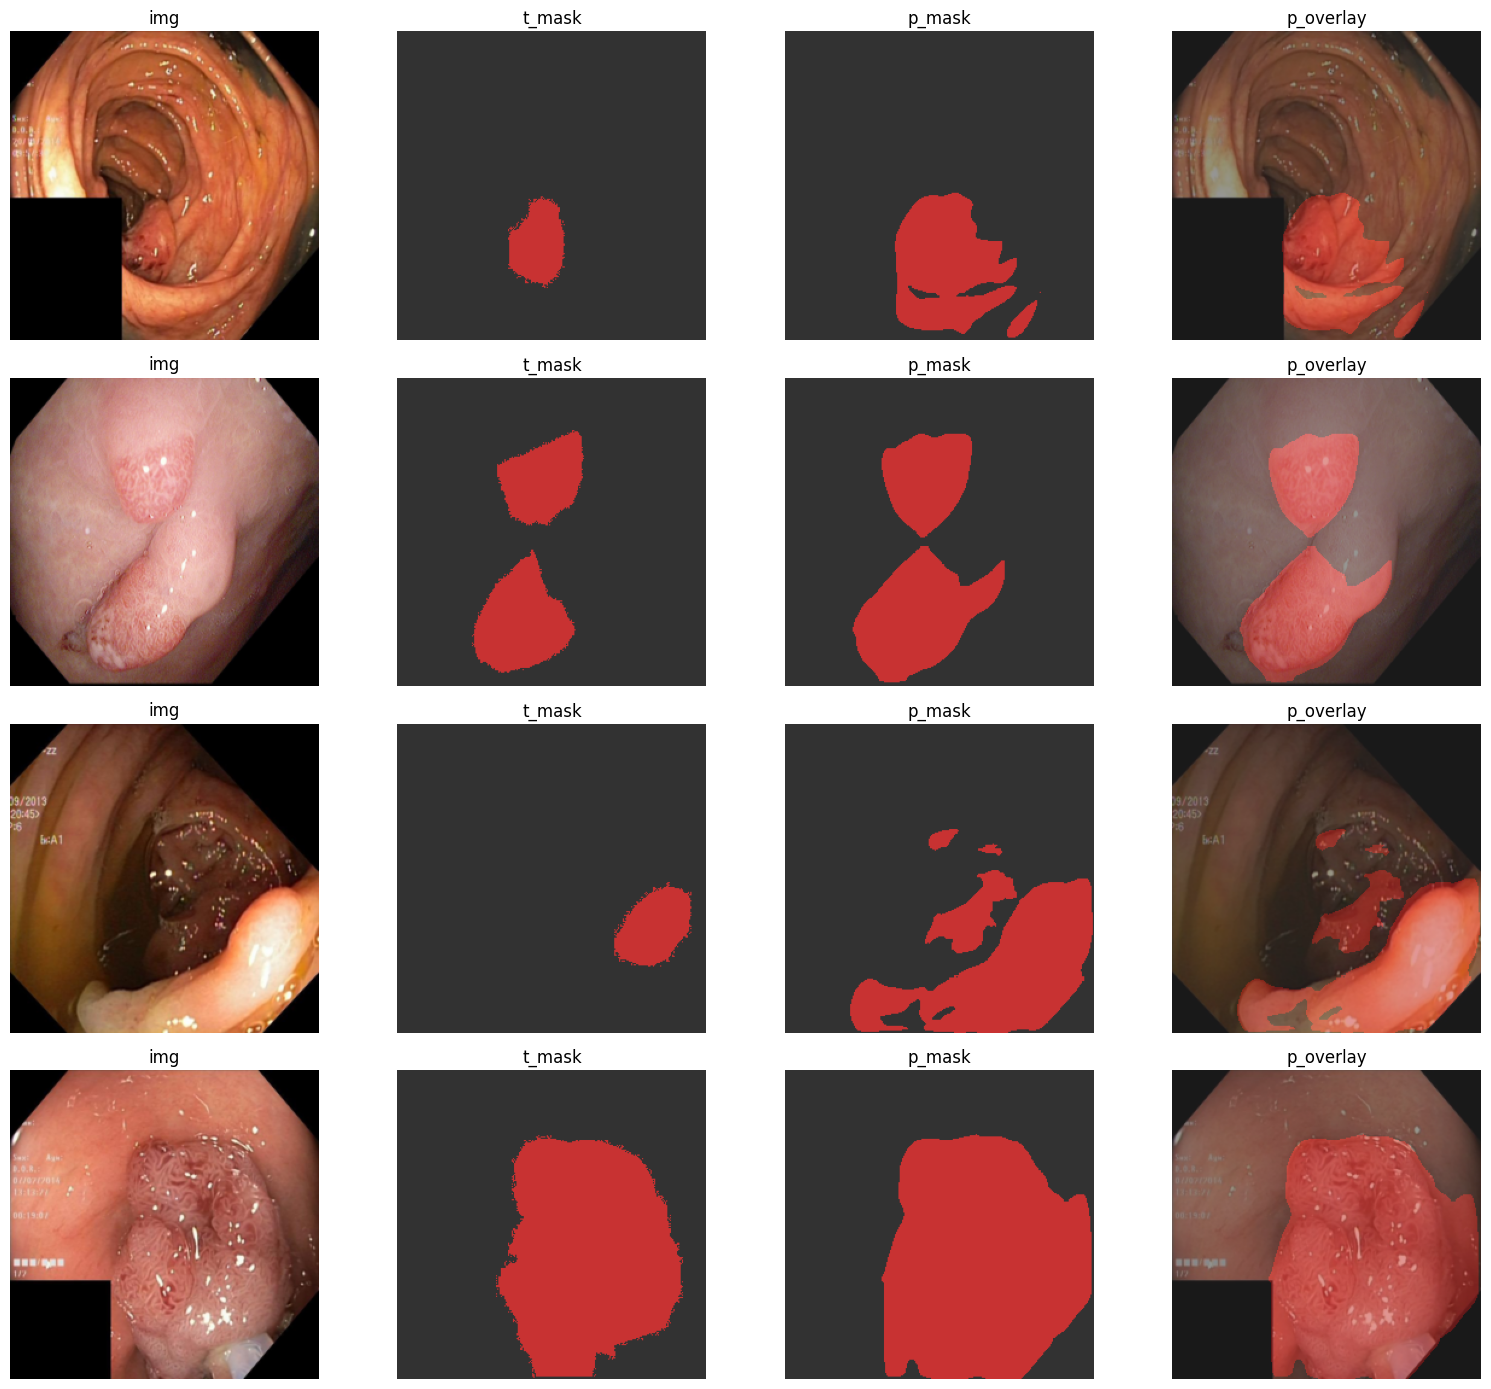

[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.44it/s]


[Epoch 5] Train Loss: 0.1594, Train mIoU: 82.20% | Val Loss: 0.2514, Val mIoU: 76.64%
✅ [Epoch 5] New best model saved! mIoU: 76.64%
EarlyStopping counter: 1 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.17it/s]


[Epoch 6] Train Loss: 0.1341, Train mIoU: 84.66% | Val Loss: 0.3249, Val mIoU: 77.28%
✅ [Epoch 6] New best model saved! mIoU: 77.28%
EarlyStopping counter: 2 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.39it/s]


[Epoch 7] Train Loss: 0.1568, Train mIoU: 81.94% | Val Loss: 0.2419, Val mIoU: 79.02%
✅ [Epoch 7] New best model saved! mIoU: 79.02%


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.21it/s]


[Epoch 8] Train Loss: 0.1201, Train mIoU: 86.12% | Val Loss: 0.2306, Val mIoU: 79.57%
✅ [Epoch 8] New best model saved! mIoU: 79.57%


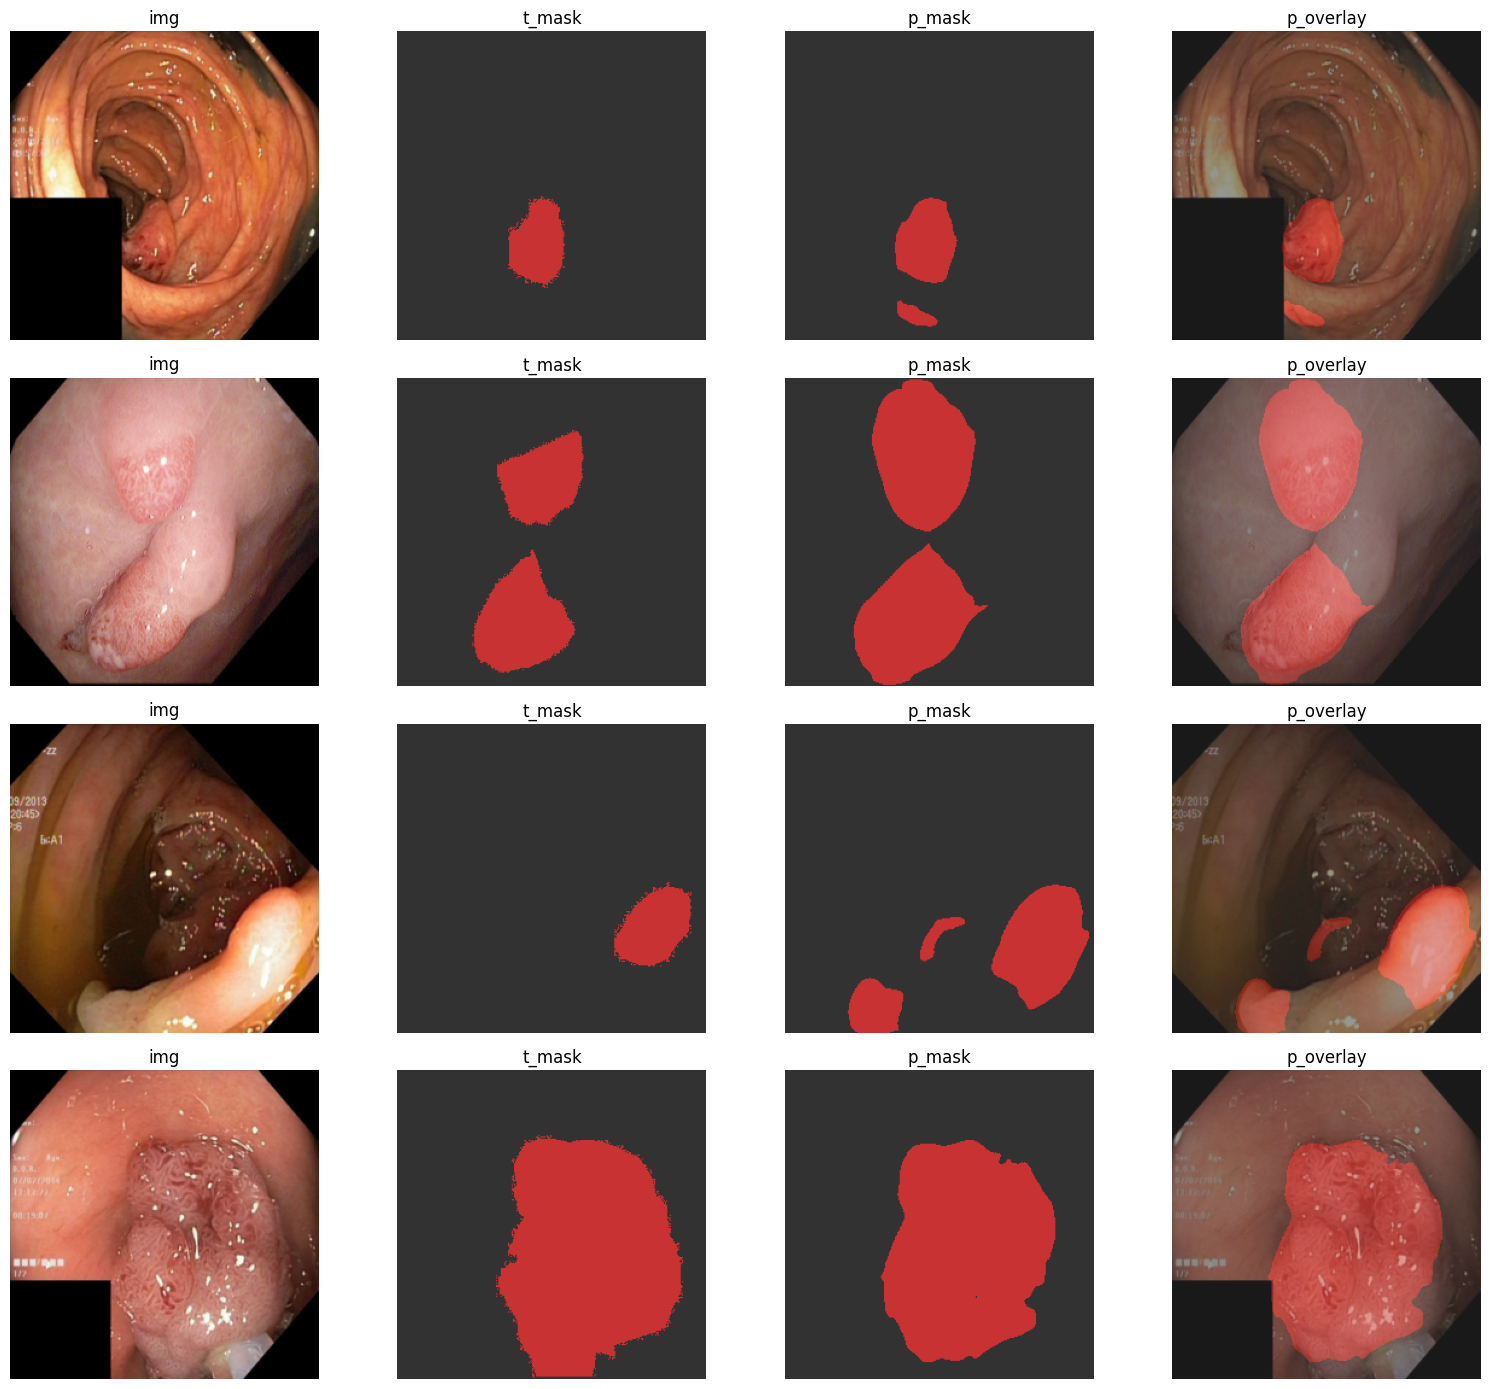

[Validation]: 100%|██████████| 8/8 [00:00<00:00,  8.85it/s]


[Epoch 9] Train Loss: 0.1123, Train mIoU: 87.01% | Val Loss: 0.2168, Val mIoU: 79.23%


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  8.93it/s]


[Epoch 10] Train Loss: 0.1200, Train mIoU: 86.14% | Val Loss: 0.3127, Val mIoU: 78.64%
EarlyStopping counter: 1 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  8.13it/s]


[Epoch 11] Train Loss: 0.1190, Train mIoU: 85.63% | Val Loss: 0.2385, Val mIoU: 76.95%
EarlyStopping counter: 2 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  8.39it/s]

[Epoch 12] Train Loss: 0.1073, Train mIoU: 87.58% | Val Loss: 0.2538, Val mIoU: 77.63%
EarlyStopping counter: 3 out of 15


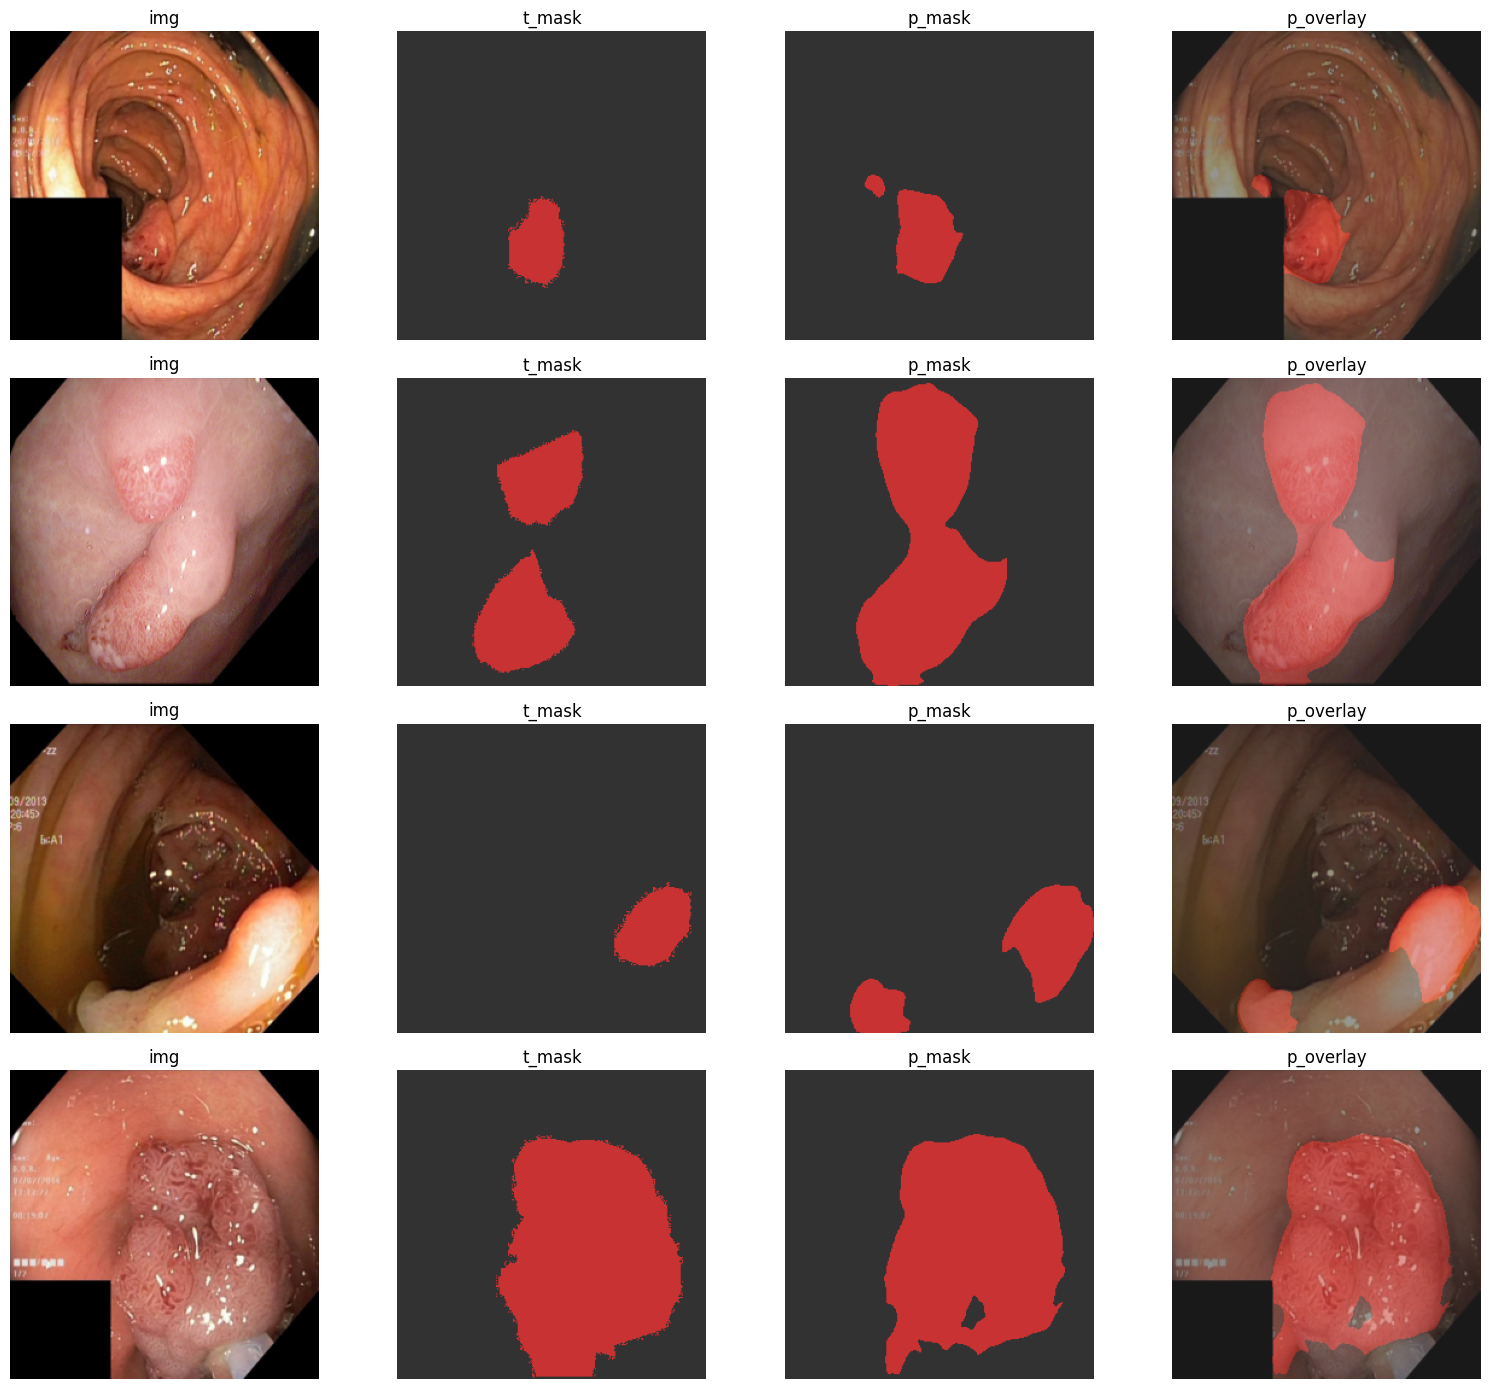

[Validation]: 100%|██████████| 8/8 [00:00<00:00,  8.55it/s]


[Epoch 13] Train Loss: 0.1222, Train mIoU: 85.38% | Val Loss: 0.2957, Val mIoU: 77.84%
EarlyStopping counter: 4 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.77it/s]


[Epoch 14] Train Loss: 0.0930, Train mIoU: 88.67% | Val Loss: 0.2398, Val mIoU: 81.76%
✅ [Epoch 14] New best model saved! mIoU: 81.76%
EarlyStopping counter: 5 out of 15


[Validation]: 100%|██████████| 8/8 [00:01<00:00,  7.76it/s]


[Epoch 15] Train Loss: 0.0796, Train mIoU: 90.02% | Val Loss: 0.2105, Val mIoU: 81.96%
✅ [Epoch 15] New best model saved! mIoU: 81.96%


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  8.68it/s]


[Epoch 16] Train Loss: 0.0722, Train mIoU: 91.13% | Val Loss: 0.2309, Val mIoU: 83.14%
✅ [Epoch 16] New best model saved! mIoU: 83.14%
EarlyStopping counter: 1 out of 15


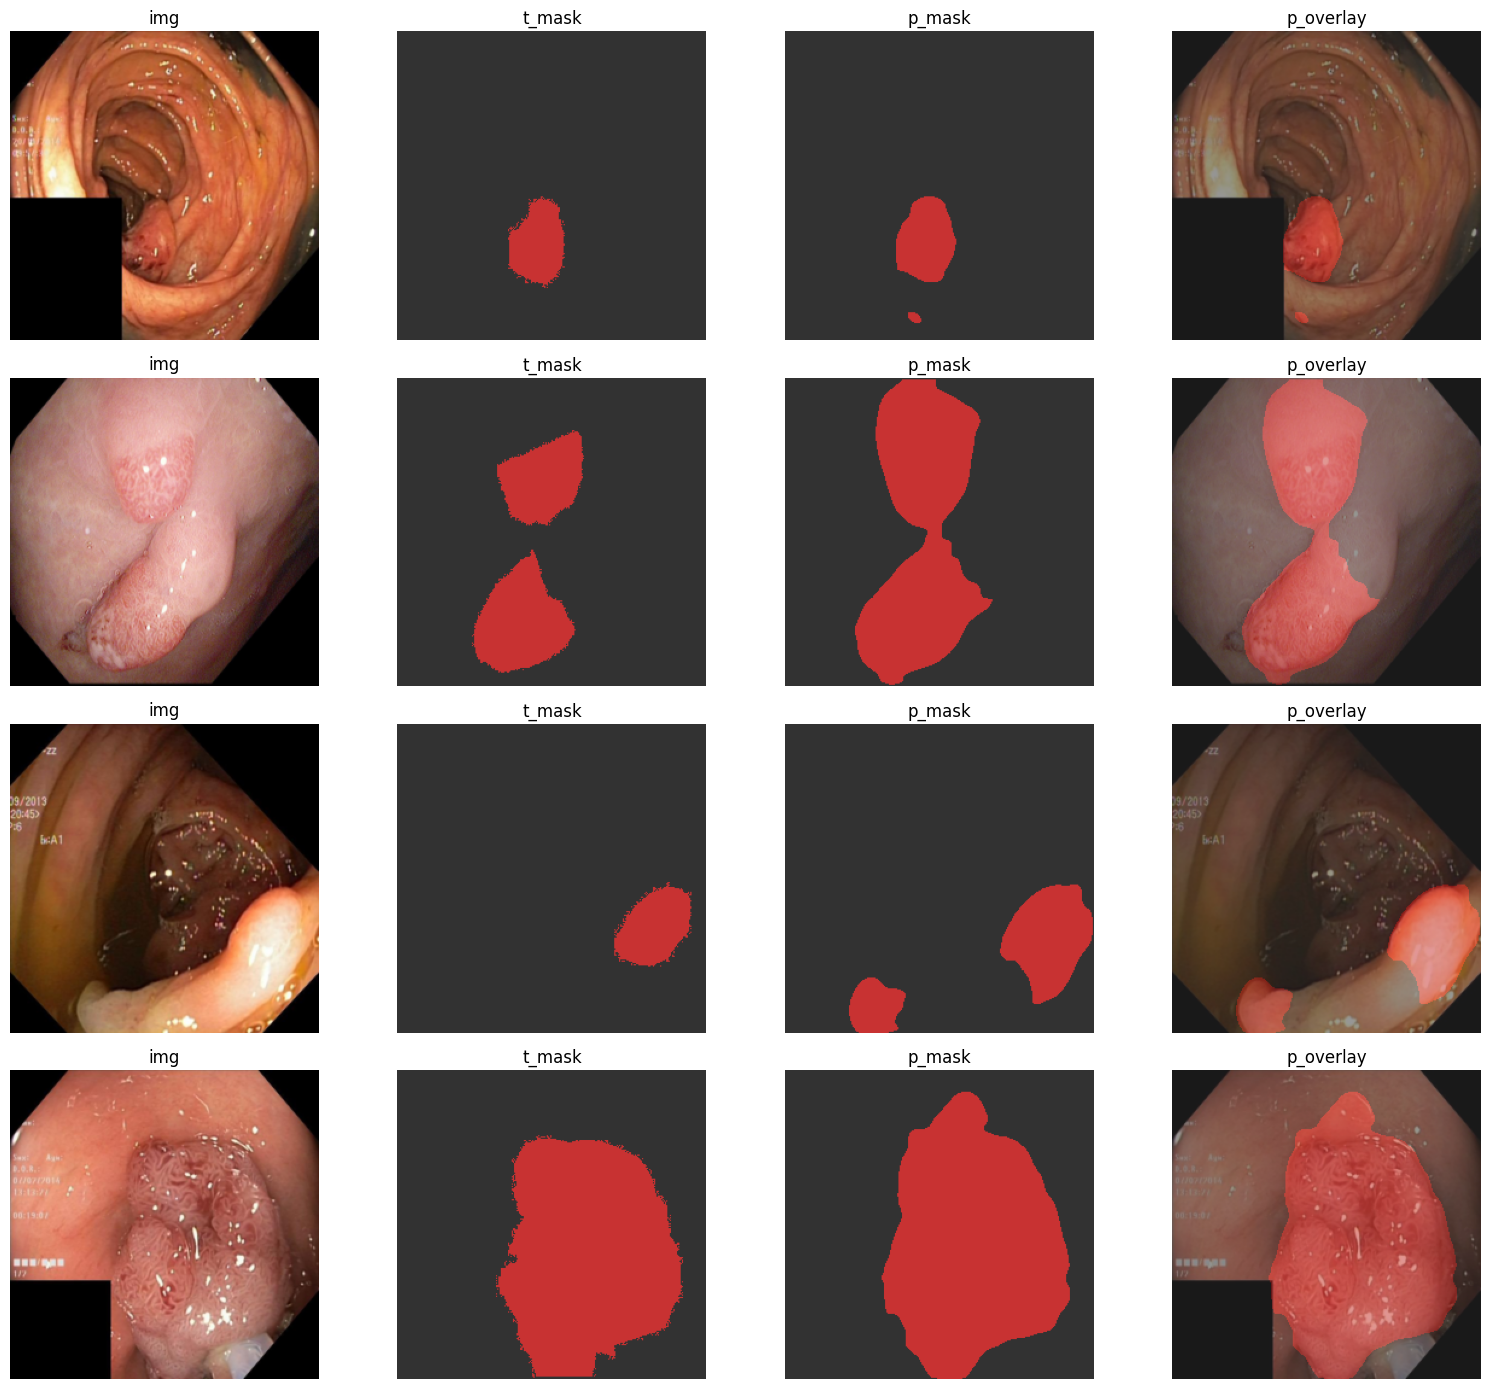

[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.72it/s]


[Epoch 17] Train Loss: 0.0683, Train mIoU: 91.20% | Val Loss: 0.2289, Val mIoU: 82.93%
EarlyStopping counter: 2 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.68it/s]


[Epoch 18] Train Loss: 0.0697, Train mIoU: 91.23% | Val Loss: 0.2118, Val mIoU: 82.84%
EarlyStopping counter: 3 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.74it/s]


[Epoch 19] Train Loss: 0.0663, Train mIoU: 91.66% | Val Loss: 0.2209, Val mIoU: 83.84%
✅ [Epoch 19] New best model saved! mIoU: 83.84%
EarlyStopping counter: 4 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.48it/s]

[Epoch 20] Train Loss: 0.0621, Train mIoU: 92.23% | Val Loss: 0.2199, Val mIoU: 83.77%
EarlyStopping counter: 5 out of 15


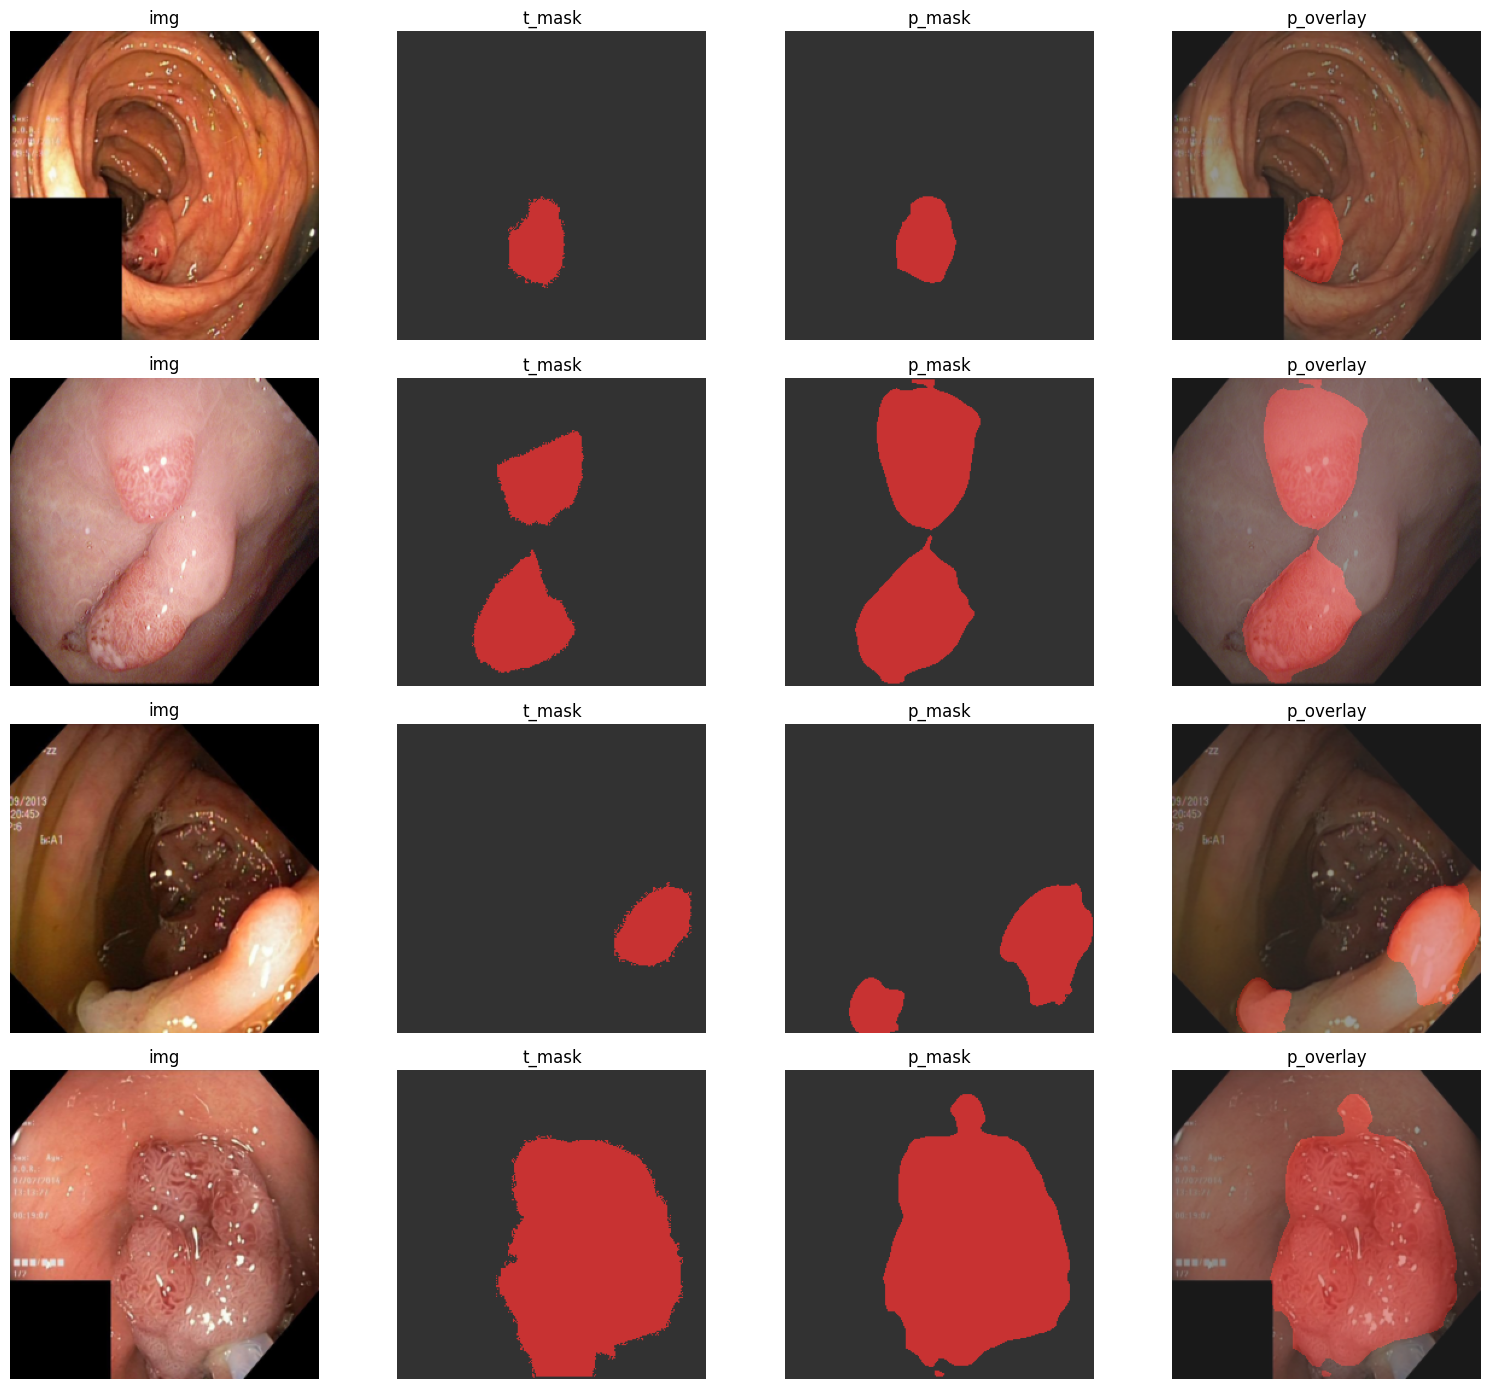

[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.39it/s]


[Epoch 21] Train Loss: 0.0616, Train mIoU: 92.16% | Val Loss: 0.2184, Val mIoU: 83.77%
EarlyStopping counter: 6 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  8.86it/s]


[Epoch 22] Train Loss: 0.0594, Train mIoU: 92.41% | Val Loss: 0.2259, Val mIoU: 84.01%
✅ [Epoch 22] New best model saved! mIoU: 84.01%
EarlyStopping counter: 7 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.06it/s]


[Epoch 23] Train Loss: 0.0610, Train mIoU: 92.19% | Val Loss: 0.2344, Val mIoU: 84.09%
✅ [Epoch 23] New best model saved! mIoU: 84.09%
EarlyStopping counter: 8 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.48it/s]

[Epoch 24] Train Loss: 0.0625, Train mIoU: 92.12% | Val Loss: 0.2181, Val mIoU: 83.69%
EarlyStopping counter: 9 out of 15


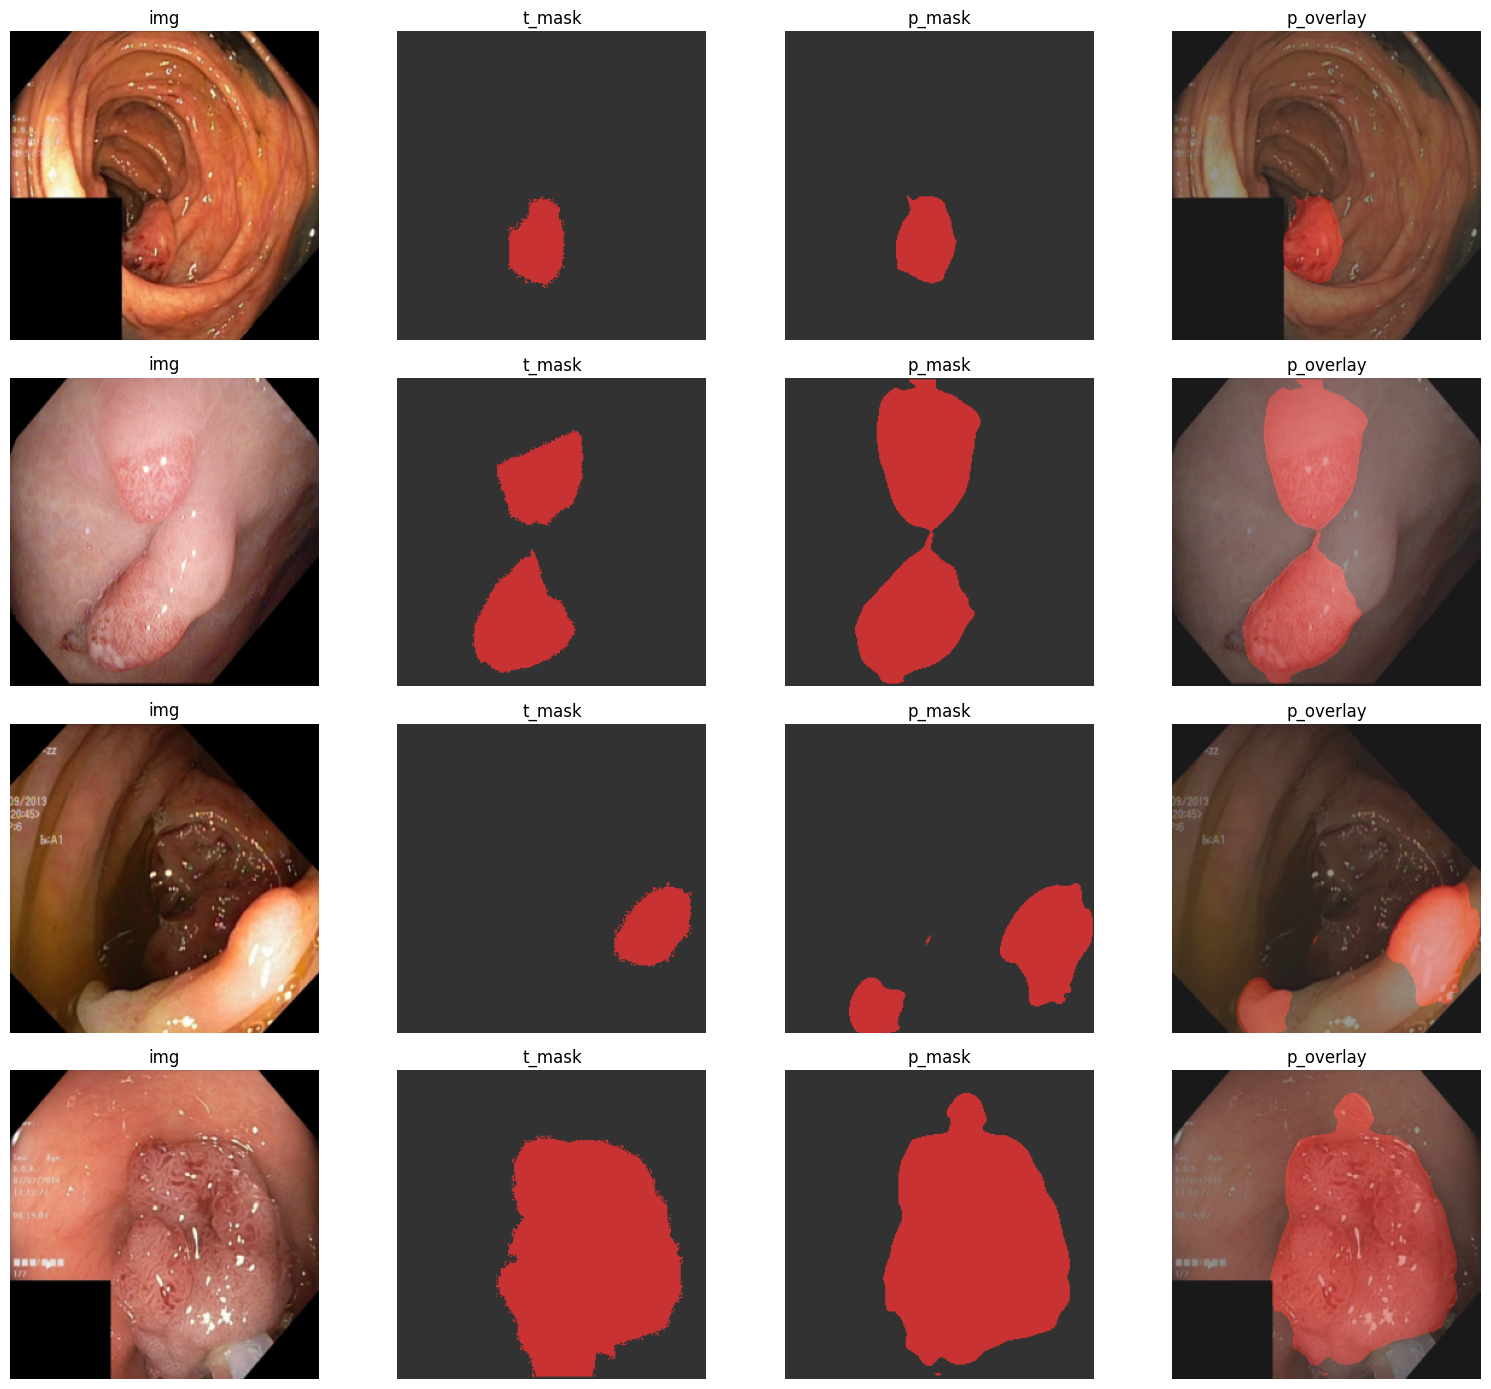

[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.71it/s]


[Epoch 25] Train Loss: 0.0589, Train mIoU: 92.46% | Val Loss: 0.2147, Val mIoU: 83.43%
EarlyStopping counter: 10 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.58it/s]


[Epoch 26] Train Loss: 0.0626, Train mIoU: 92.06% | Val Loss: 0.2151, Val mIoU: 83.44%
EarlyStopping counter: 11 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.49it/s]


[Epoch 27] Train Loss: 0.0618, Train mIoU: 92.14% | Val Loss: 0.2263, Val mIoU: 83.93%
EarlyStopping counter: 12 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.71it/s]

[Epoch 28] Train Loss: 0.0599, Train mIoU: 92.36% | Val Loss: 0.2240, Val mIoU: 83.93%
EarlyStopping counter: 13 out of 15


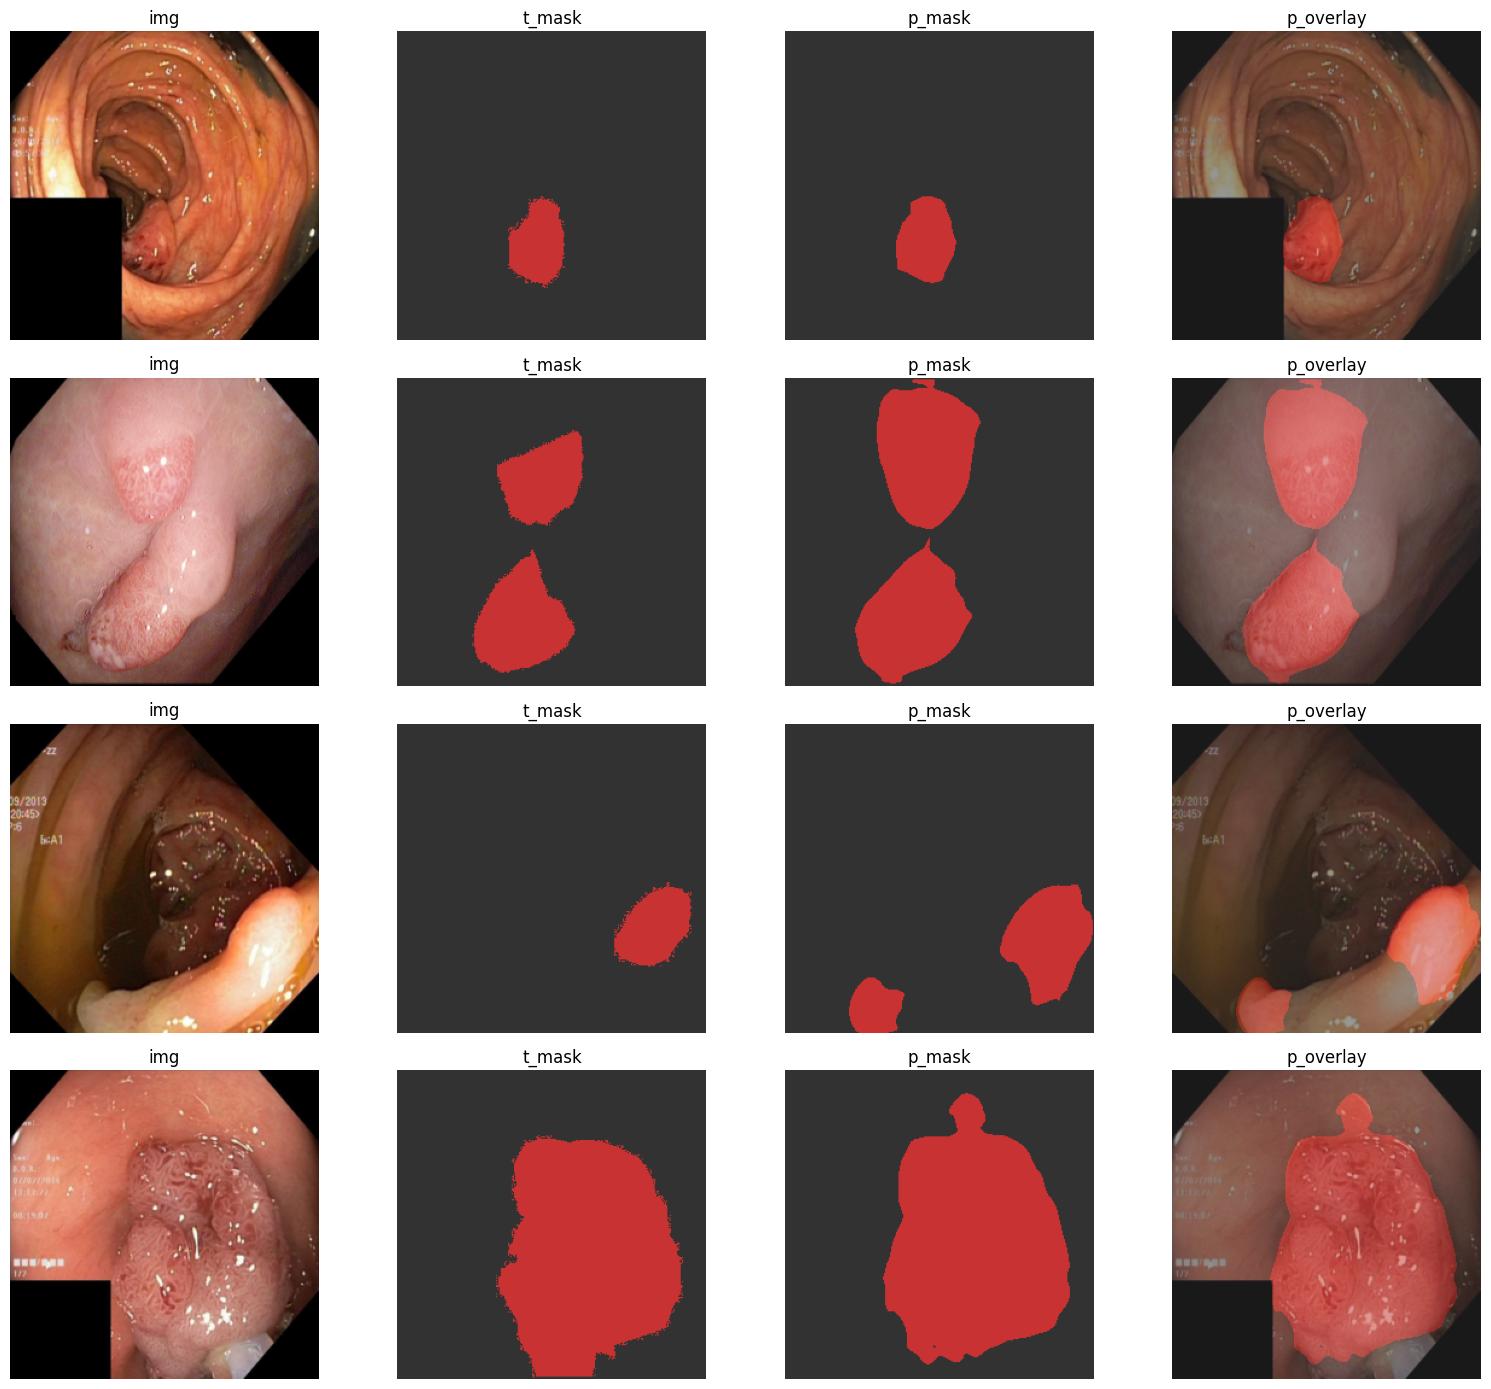

[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.79it/s]


[Epoch 29] Train Loss: 0.0617, Train mIoU: 92.07% | Val Loss: 0.2255, Val mIoU: 83.85%
EarlyStopping counter: 14 out of 15


[Validation]: 100%|██████████| 8/8 [00:00<00:00,  9.34it/s]

[Epoch 30] Train Loss: 0.0592, Train mIoU: 92.27% | Val Loss: 0.2249, Val mIoU: 83.97%
EarlyStopping counter: 15 out of 15
⚠️ Early stopping triggered after 15 epochs of no improvement.
--- 학습 최종 종료 ---


In [11]:
history = {'train_loss': [], 'val_loss': [], 'train_miou': [], 'val_miou': []}
best_miou = 0.0
best_val_loss = float('inf')
patience = 15
counter = 0

print("--- 학습 시작 ---")
for ep in range(1, EPOCHS + 1):
    train_loss, tr_miou = train(m, criterion, optimizer, scaler, tr_loader, DEVICE)
    val_loss, val_miou = evaluate(m, val_loader, DEVICE, criterion)
    scheduler.step(val_loss)

    # history에 기록
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_miou'].append(tr_miou)
    history['val_miou'].append(val_miou)

    print(f"[Epoch {ep}] Train Loss: {train_loss:.4f}, Train mIoU: {tr_miou*100:.2f}% | Val Loss: {val_loss:.4f}, Val mIoU: {val_miou*100:.2f}%")

    # Best mIoU 모델 저장
    if val_miou > best_miou:
        best_miou = val_miou
        torch.save({
            'epoch': ep,
            'model': m.state_dict(),
            'miou': best_miou,
            'config': {
                'IMG_SIZE': IMG_SIZE,
                'N_CLASSES': N_CLASSES,
                "LR": LR,
                "WEIGHT_DECAY": WEIGHT_DECAY
            }
        }, BEST_PATH)
        print(f'✅ [Epoch {ep}] New best model saved! mIoU: {best_miou*100:.2f}%')

    # Early Stopping 로직
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
    else:
        counter += 1
        print(f'EarlyStopping counter: {counter} out of {patience}')

    if counter >= patience:
        print(f'⚠️ Early stopping triggered after {patience} epochs of no improvement.')
        break

    # 4 epoch 마다 샘플 이미지 확인
    if ep % 4 == 0:
        show_samples(model=m, loader=val_loader, max_rows=4)

print("--- 학습 최종 종료 ---")